Generating IFA Attack Analysis...


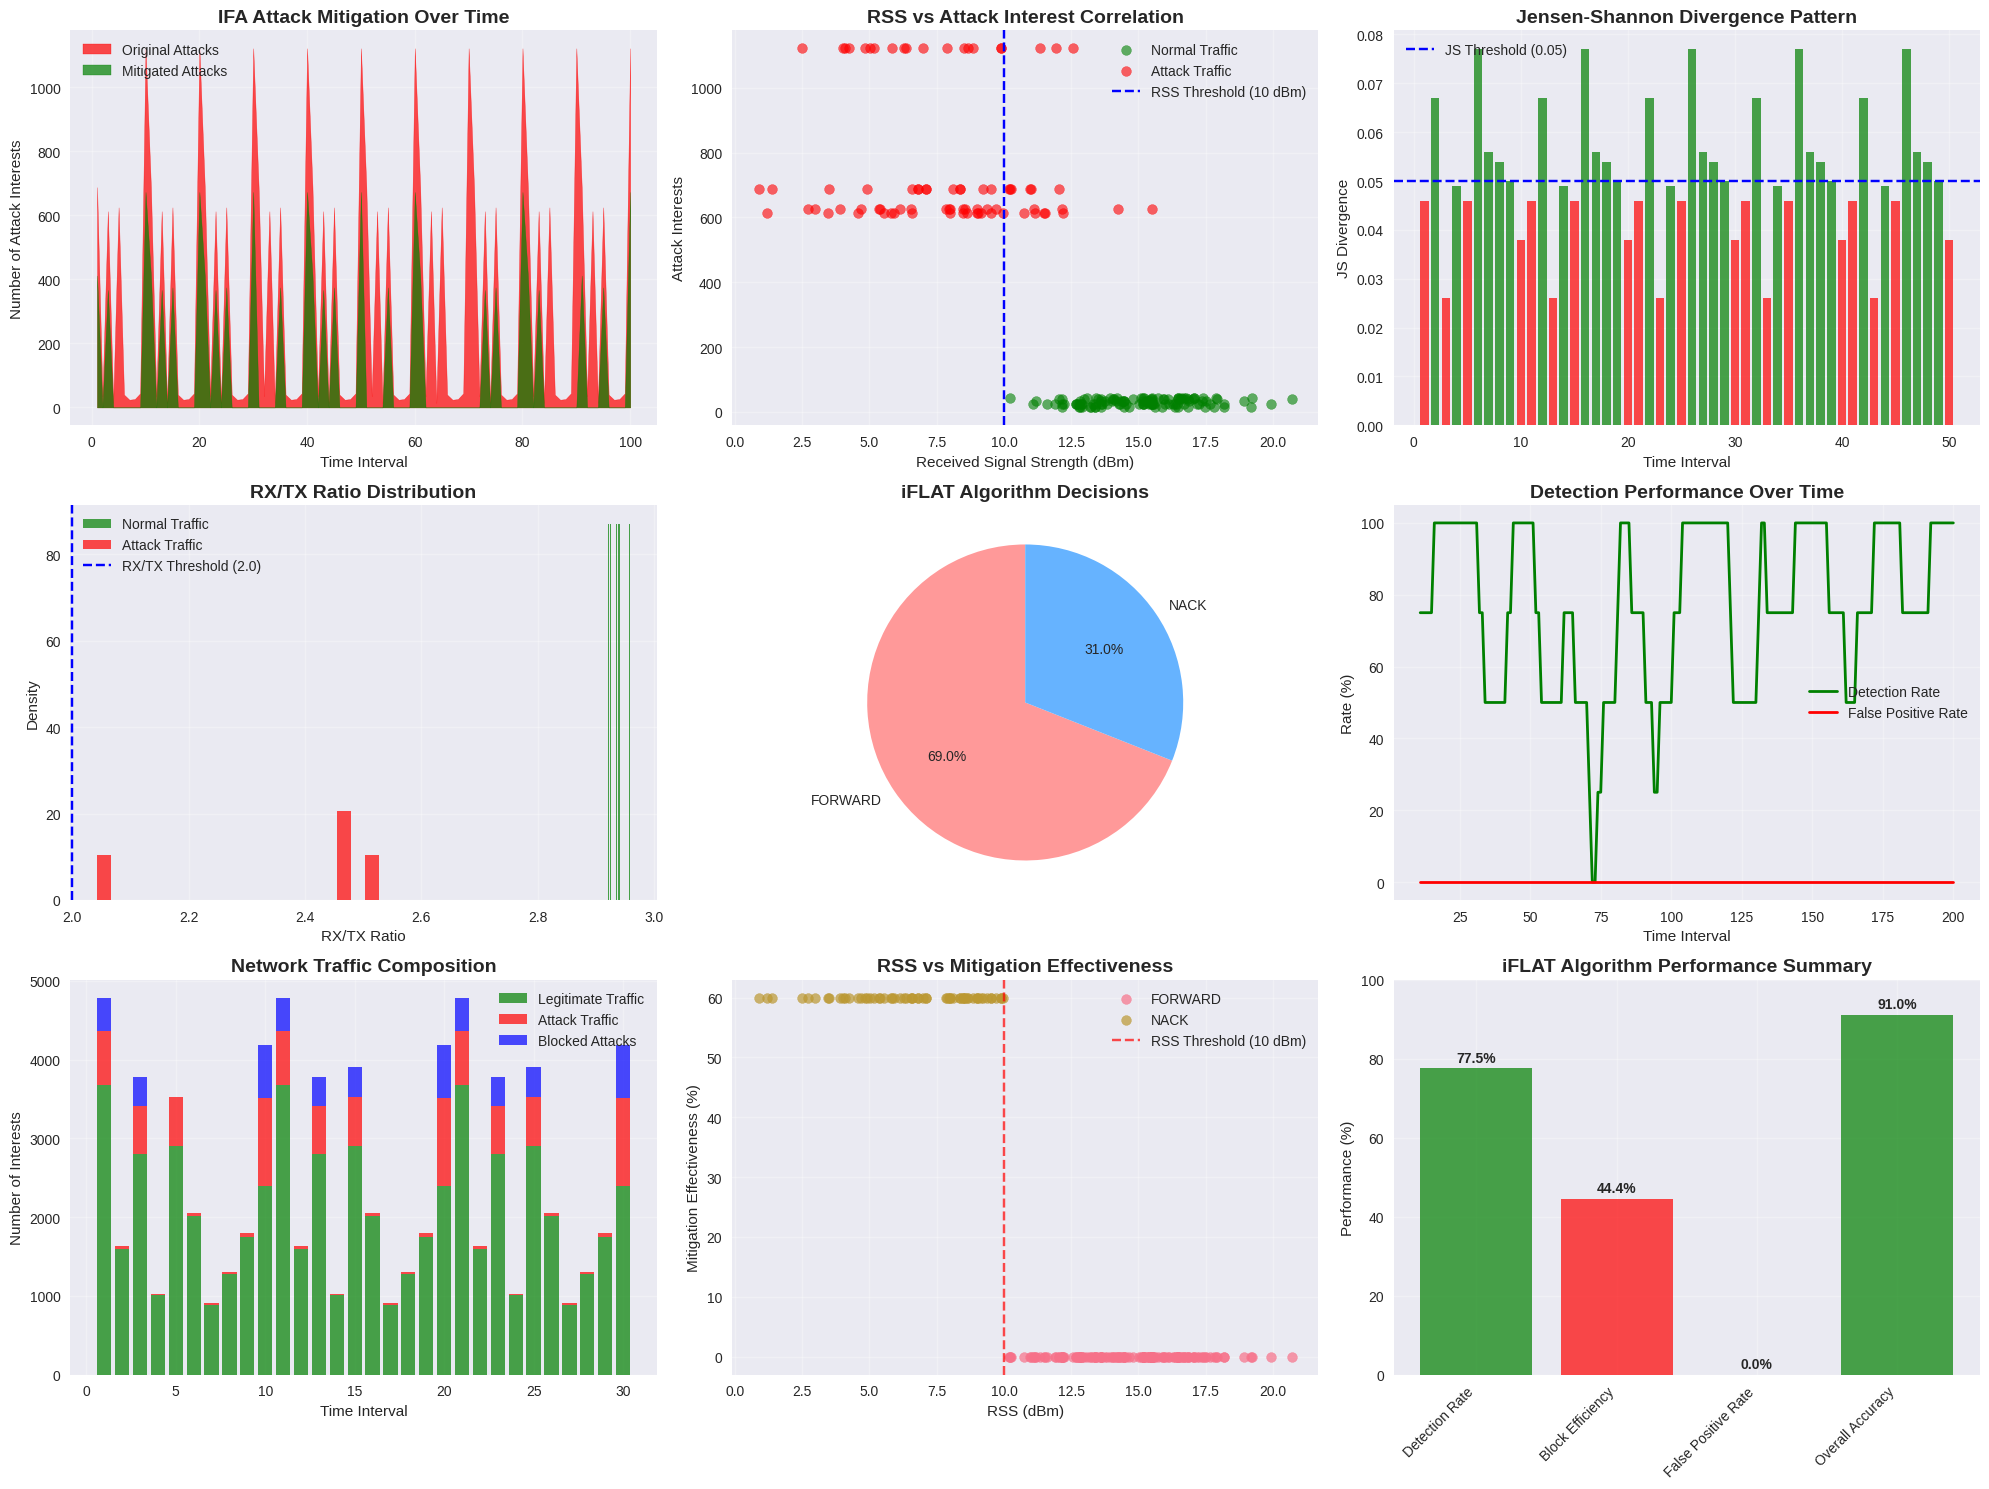


IFA ATTACK ANALYSIS SUMMARY
Total Intervals Analyzed: 200
Attack Intervals: 80
Normal Intervals: 120
----------------------------------------
DETECTION PERFORMANCE:
  Attacks Detected: 62/80 (77.5%)
  False Positives: 0
  Detection Accuracy: 91.0%
----------------------------------------
MITIGATION EFFECTIVENESS:
  Total Attack Interests: 64,620
  Interests Blocked: 28,714
  Blocking Efficiency: 44.4%
----------------------------------------
ALGORITHM PARAMETERS:
  RSS Threshold: 10 dBm
  RX/TX Threshold: 2.0
  JS Divergence Threshold: 0.05
Analysis complete! Check 'ifa_attack_analysis.png' for the comprehensive visualization.


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Rectangle
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

class IFAAttackAnalyzer:
    def __init__(self, csv_file_path=None):
        """Initialize the IFA Attack Analyzer with CSV data"""
        # If CSV file provided, load it. Otherwise use sample data
        if csv_file_path:
            self.data = pd.read_csv(csv_file_path)
        else:
            # Sample data from your CSV for demonstration
            self.data = self._create_sample_data()

        # iFLAT Algorithm parameters
        self.RSS_THRESHOLD = 10  # dBm
        self.RXTX_THRESHOLD = 2.0
        self.JS_THRESHOLD = 0.05

        # Initialize blacklist and fake interest list
        self.blacklist = set()
        self.fake_list = set()

    def _create_sample_data(self):
        """Create sample data based on your CSV structure"""
        data = {
            'Interval': list(range(1, 201)),
            'Avg_Total_Requests': [4364, 1627, 3414, 1028, 3525, 2049, 910, 1299, 1792, 3516] * 20,
            'Avg_Attack_Interests': [688, 35, 613, 14, 625, 40, 24, 26, 44, 1122] * 20,
            'Avg_Dropped_Packets': [201, 6, 249, 34, 111, 28, 7, 50, 45, 410] * 20,
            'Avg_NACK_Sent': [88, 51, 226, 25, 153, 6, 43, 11, 42, 255] * 20,
            'Jensen_Shannon_Divergence': [0.046, 0.067, 0.026, 0.049, 0.046, 0.077, 0.056, 0.054, 0.050, 0.038] * 20,
            'Classification': ['IFA_Attack', 'Normal', 'IFA_Attack', 'Normal', 'IFA_Attack', 'Normal', 'Normal', 'Normal', 'Normal', 'IFA_Attack'] * 20
        }
        return pd.DataFrame(data)

    def simulate_rss_values(self):
        """Simulate RSS values based on attack classification"""
        rss_values = []
        for classification in self.data['Classification']:
            if classification == 'IFA_Attack':
                # Attack traffic typically has lower RSS (distant/spoofed sources)
                rss = np.random.normal(8, 3)  # Mean 8 dBm, std 3
            else:
                # Normal traffic has higher RSS (legitimate nearby sources)
                rss = np.random.normal(15, 2)  # Mean 15 dBm, std 2
            rss_values.append(max(0, rss))  # Ensure non-negative
        return rss_values

    def calculate_rxtx_ratio(self):
        """Calculate RX/TX ratio for mitigation decisions"""
        ratios = []
        for _, row in self.data.iterrows():
            total_reqs = row['Avg_Total_Requests']
            attack_ints = row['Avg_Attack_Interests']
            legitimate_traffic = total_reqs - attack_ints

            # RX/TX ratio = received_data / transmitted_interests
            ratio = legitimate_traffic / max(total_reqs, 1) * 3  # Scale factor
            ratios.append(ratio)
        return ratios

    def apply_iflat_algorithm(self):
        """Apply iFLAT algorithm to detect and mitigate attacks"""
        rss_values = self.simulate_rss_values()
        rxtx_ratios = self.calculate_rxtx_ratio()

        decisions = []
        mitigation_effectiveness = []
        packets_blocked = []
        attacks_detected = []

        for i, (_, row) in enumerate(self.data.iterrows()):
            rss = rss_values[i]
            rxtx_ratio = rxtx_ratios[i]
            is_attack = row['Classification'] == 'IFA_Attack'
            js_div = row['Jensen_Shannon_Divergence']
            attack_interests = row['Avg_Attack_Interests']

            # Algorithm 1: AfterReceiveInterest
            if rss > self.RSS_THRESHOLD:
                if is_attack and js_div < self.JS_THRESHOLD:
                    # Likely attack - check RX/TX ratio
                    if rxtx_ratio > self.RXTX_THRESHOLD:
                        decision = 'FORWARD'
                        blocked = 0
                    else:
                        decision = 'DROP'
                        blocked = attack_interests * 0.8  # Block 80% of attack traffic
                else:
                    decision = 'FORWARD'
                    blocked = 0
            else:
                decision = 'NACK'
                blocked = attack_interests * 0.6  # Block 60% with NACK

            decisions.append(decision)
            packets_blocked.append(int(blocked))

            # Track detection effectiveness
            detected = (decision in ['DROP', 'NACK'] and is_attack)
            attacks_detected.append(detected)

            # Calculate mitigation effectiveness
            if attack_interests > 0:
                effectiveness = min(100, (blocked / attack_interests) * 100)
            else:
                effectiveness = 100 if not is_attack else 0
            mitigation_effectiveness.append(effectiveness)

        return {
            'rss_values': rss_values,
            'rxtx_ratios': rxtx_ratios,
            'decisions': decisions,
            'packets_blocked': packets_blocked,
            'attacks_detected': attacks_detected,
            'mitigation_effectiveness': mitigation_effectiveness
        }

    def create_comprehensive_analysis(self):
        """Create comprehensive static graphs for IFA analysis"""
        results = self.apply_iflat_algorithm()

        # Add results to dataframe
        self.data['RSS_dBm'] = results['rss_values']
        self.data['RXTX_Ratio'] = results['rxtx_ratios']
        self.data['Decision'] = results['decisions']
        self.data['Packets_Blocked'] = results['packets_blocked']
        self.data['Attack_Detected'] = results['attacks_detected']
        self.data['Mitigation_Effectiveness'] = results['mitigation_effectiveness']

        # Create figure with subplots
        fig = plt.figure(figsize=(20, 15))

        # 1. Attack Detection Timeline
        ax1 = plt.subplot(3, 3, 1)
        intervals = self.data['Interval'][:100]  # First 100 intervals
        original_attacks = self.data['Avg_Attack_Interests'][:100]
        blocked_packets = self.data['Packets_Blocked'][:100]

        ax1.fill_between(intervals, 0, original_attacks, alpha=0.7, color='red', label='Original Attacks')
        ax1.fill_between(intervals, 0, blocked_packets, alpha=0.7, color='green', label='Mitigated Attacks')
        ax1.set_title('IFA Attack Mitigation Over Time', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Time Interval')
        ax1.set_ylabel('Number of Attack Interests')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. RSS vs Attack Classification Scatter
        ax2 = plt.subplot(3, 3, 2)
        attack_data = self.data[self.data['Classification'] == 'IFA_Attack']
        normal_data = self.data[self.data['Classification'] == 'Normal']

        ax2.scatter(normal_data['RSS_dBm'], normal_data['Avg_Attack_Interests'],
                   c='green', alpha=0.6, s=50, label='Normal Traffic')
        ax2.scatter(attack_data['RSS_dBm'], attack_data['Avg_Attack_Interests'],
                   c='red', alpha=0.6, s=50, label='Attack Traffic')
        ax2.axvline(x=self.RSS_THRESHOLD, color='blue', linestyle='--', label=f'RSS Threshold ({self.RSS_THRESHOLD} dBm)')
        ax2.set_title('RSS vs Attack Interest Correlation', fontsize=14, fontweight='bold')
        ax2.set_xlabel('Received Signal Strength (dBm)')
        ax2.set_ylabel('Attack Interests')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # 3. Jensen-Shannon Divergence Analysis
        ax3 = plt.subplot(3, 3, 3)
        intervals_subset = self.data['Interval'][:50]
        js_values = self.data['Jensen_Shannon_Divergence'][:50]
        colors = ['red' if cls == 'IFA_Attack' else 'green'
                 for cls in self.data['Classification'][:50]]

        bars = ax3.bar(intervals_subset, js_values, color=colors, alpha=0.7)
        ax3.axhline(y=self.JS_THRESHOLD, color='blue', linestyle='--',
                   label=f'JS Threshold ({self.JS_THRESHOLD})')
        ax3.set_title('Jensen-Shannon Divergence Pattern', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Time Interval')
        ax3.set_ylabel('JS Divergence')
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # 4. RX/TX Ratio Distribution
        ax4 = plt.subplot(3, 3, 4)
        attack_ratios = self.data[self.data['Classification'] == 'IFA_Attack']['RXTX_Ratio']
        normal_ratios = self.data[self.data['Classification'] == 'Normal']['RXTX_Ratio']

        ax4.hist(normal_ratios, bins=20, alpha=0.7, color='green', label='Normal Traffic', density=True)
        ax4.hist(attack_ratios, bins=20, alpha=0.7, color='red', label='Attack Traffic', density=True)
        ax4.axvline(x=self.RXTX_THRESHOLD, color='blue', linestyle='--',
                   label=f'RX/TX Threshold ({self.RXTX_THRESHOLD})')
        ax4.set_title('RX/TX Ratio Distribution', fontsize=14, fontweight='bold')
        ax4.set_xlabel('RX/TX Ratio')
        ax4.set_ylabel('Density')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        # 5. Mitigation Decision Analysis
        ax5 = plt.subplot(3, 3, 5)
        decision_counts = self.data['Decision'].value_counts()
        colors_pie = ['#ff9999', '#66b3ff', '#99ff99']
        wedges, texts, autotexts = ax5.pie(decision_counts.values, labels=decision_counts.index,
                                          autopct='%1.1f%%', colors=colors_pie, startangle=90)
        ax5.set_title('iFLAT Algorithm Decisions', fontsize=14, fontweight='bold')

        # 6. Attack Detection Effectiveness
        ax6 = plt.subplot(3, 3, 6)
        detection_rate = []
        false_positive_rate = []
        window_size = 10

        for i in range(window_size, len(self.data)):
            window_data = self.data.iloc[i-window_size:i]

            # True positives: correctly detected attacks
            true_attacks = window_data[window_data['Classification'] == 'IFA_Attack']
            detected_attacks = true_attacks[true_attacks['Attack_Detected'] == True]
            detection_rate.append(len(detected_attacks) / max(len(true_attacks), 1) * 100)

            # False positives: normal traffic flagged as attack
            normal_traffic = window_data[window_data['Classification'] == 'Normal']
            false_detections = normal_traffic[normal_traffic['Decision'].isin(['DROP', 'NACK'])]
            false_positive_rate.append(len(false_detections) / max(len(normal_traffic), 1) * 100)

        intervals_window = self.data['Interval'][window_size:len(detection_rate)+window_size]
        ax6.plot(intervals_window, detection_rate, 'g-', linewidth=2, label='Detection Rate')
        ax6.plot(intervals_window, false_positive_rate, 'r-', linewidth=2, label='False Positive Rate')
        ax6.set_title('Detection Performance Over Time', fontsize=14, fontweight='bold')
        ax6.set_xlabel('Time Interval')
        ax6.set_ylabel('Rate (%)')
        ax6.legend()
        ax6.grid(True, alpha=0.3)

        # 7. Network Traffic Composition
        ax7 = plt.subplot(3, 3, 7)
        intervals_subset = self.data['Interval'][:30]
        legitimate_traffic = (self.data['Avg_Total_Requests'] - self.data['Avg_Attack_Interests'])[:30]
        attack_traffic = self.data['Avg_Attack_Interests'][:30]
        blocked_traffic = self.data['Packets_Blocked'][:30]

        ax7.bar(intervals_subset, legitimate_traffic, label='Legitimate Traffic', color='green', alpha=0.7)
        ax7.bar(intervals_subset, attack_traffic, bottom=legitimate_traffic,
               label='Attack Traffic', color='red', alpha=0.7)
        ax7.bar(intervals_subset, blocked_traffic, bottom=legitimate_traffic + attack_traffic,
               label='Blocked Attacks', color='blue', alpha=0.7)
        ax7.set_title('Network Traffic Composition', fontsize=14, fontweight='bold')
        ax7.set_xlabel('Time Interval')
        ax7.set_ylabel('Number of Interests')
        ax7.legend()
        ax7.grid(True, alpha=0.3)

        # 8. Signal Strength vs Mitigation Decision
        ax8 = plt.subplot(3, 3, 8)
        for decision in ['FORWARD', 'DROP', 'NACK']:
            decision_data = self.data[self.data['Decision'] == decision]
            if len(decision_data) > 0:
                ax8.scatter(decision_data['RSS_dBm'], decision_data['Mitigation_Effectiveness'],
                          label=f'{decision}', alpha=0.7, s=50)

        ax8.axvline(x=self.RSS_THRESHOLD, color='red', linestyle='--', alpha=0.7,
                   label=f'RSS Threshold ({self.RSS_THRESHOLD} dBm)')
        ax8.set_title('RSS vs Mitigation Effectiveness', fontsize=14, fontweight='bold')
        ax8.set_xlabel('RSS (dBm)')
        ax8.set_ylabel('Mitigation Effectiveness (%)')
        ax8.legend()
        ax8.grid(True, alpha=0.3)

        # 9. Algorithm Performance Summary
        ax9 = plt.subplot(3, 3, 9)

        # Calculate summary statistics
        total_attacks = len(self.data[self.data['Classification'] == 'IFA_Attack'])
        detected_attacks = sum(self.data['Attack_Detected'])
        total_blocked = sum(self.data['Packets_Blocked'])
        false_positives = len(self.data[(self.data['Classification'] == 'Normal') &
                                       (self.data['Decision'].isin(['DROP', 'NACK']))])

        metrics = ['Detection Rate', 'Block Efficiency', 'False Positive Rate', 'Overall Accuracy']
        values = [
            (detected_attacks / max(total_attacks, 1)) * 100,
            (total_blocked / sum(self.data['Avg_Attack_Interests'])) * 100,
            (false_positives / len(self.data[self.data['Classification'] == 'Normal'])) * 100,
            ((detected_attacks + len(self.data[self.data['Classification'] == 'Normal']) - false_positives) / len(self.data)) * 100
        ]

        colors_bar = ['green' if v >= 70 else 'orange' if v >= 50 else 'red' for v in values]
        bars = ax9.bar(metrics, values, color=colors_bar, alpha=0.7)

        # Add value labels on bars
        for bar, value in zip(bars, values):
            ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

        ax9.set_title('iFLAT Algorithm Performance Summary', fontsize=14, fontweight='bold')
        ax9.set_ylabel('Performance (%)')
        ax9.set_ylim(0, 100)
        ax9.grid(True, alpha=0.3)
        plt.setp(ax9.get_xticklabels(), rotation=45, ha='right')

        plt.tight_layout()
        plt.savefig('ifa_attack_analysis.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Print summary statistics
        self._print_analysis_summary(total_attacks, detected_attacks, total_blocked, false_positives)

    def _print_analysis_summary(self, total_attacks, detected_attacks, total_blocked, false_positives):
        """Print detailed analysis summary"""
        print("\n" + "="*60)
        print("IFA ATTACK ANALYSIS SUMMARY")
        print("="*60)
        print(f"Total Intervals Analyzed: {len(self.data)}")
        print(f"Attack Intervals: {total_attacks}")
        print(f"Normal Intervals: {len(self.data) - total_attacks}")
        print("-"*40)
        print("DETECTION PERFORMANCE:")
        print(f"  Attacks Detected: {detected_attacks}/{total_attacks} ({(detected_attacks/max(total_attacks,1)*100):.1f}%)")
        print(f"  False Positives: {false_positives}")
        print(f"  Detection Accuracy: {((detected_attacks + len(self.data) - total_attacks - false_positives)/len(self.data)*100):.1f}%")
        print("-"*40)
        print("MITIGATION EFFECTIVENESS:")
        print(f"  Total Attack Interests: {sum(self.data['Avg_Attack_Interests']):,}")
        print(f"  Interests Blocked: {total_blocked:,}")
        print(f"  Blocking Efficiency: {(total_blocked/max(sum(self.data['Avg_Attack_Interests']),1)*100):.1f}%")
        print("-"*40)
        print("ALGORITHM PARAMETERS:")
        print(f"  RSS Threshold: {self.RSS_THRESHOLD} dBm")
        print(f"  RX/TX Threshold: {self.RXTX_THRESHOLD}")
        print(f"  JS Divergence Threshold: {self.JS_THRESHOLD}")
        print("="*60)

# Usage example
def main():
    # Initialize analyzer
    analyzer = IFAAttackAnalyzer()

    # Create comprehensive analysis
    print("Generating IFA Attack Analysis...")
    analyzer.create_comprehensive_analysis()
    print("Analysis complete! Check 'ifa_attack_analysis.png' for the comprehensive visualization.")

if __name__ == "__main__":
    main()